
## Budowa i Trening Modelu GNN (Graph Neural Network)
#### W przeciwieństwie do MLP, ta sieć uczy się bezpośrednio na strukturze grafowej molekuł (Atomy jako Węzły, Wiązania jako Krawędzie).


In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import polars as pl
import numpy as np
import matplotlib.pyplot as plt

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, global_mean_pool
from rdkit import Chem
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

print(f"PyTorch Geometric załadowany pomyślnie! Wersja: {torch.__version__}")

PyTorch Geometric załadowany pomyślnie! Wersja: 2.2.2



### 1. Konwersja SMILES do Obiektów Graph (PyTorch Geometric `Data`)

In [17]:

def smiles_to_graph(smiles, target_val):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    
    # Cechy węzłów (Rejestrujemy 5 podstawowych atrybutów dla każdego atomu)
    atom_features = []
    for atom in mol.GetAtoms():
        features = [
            atom.GetAtomicNum() / 100.0,      # znormalizowane
            atom.GetDegree() / 6.0,
            atom.GetFormalCharge(),
            atom.GetNumRadicalElectrons(),
            int(atom.GetIsAromatic()),
            int(atom.IsInRing()),              # ← nowe
            atom.GetTotalNumHs() / 4.0,       # ← nowe (znormalizowane)
            # hybridyzacja (SP=0, SP2=1, SP3=2)
            {Chem.rdchem.HybridizationType.SP: 0,
            Chem.rdchem.HybridizationType.SP2: 1,
            Chem.rdchem.HybridizationType.SP3: 2
            }.get(atom.GetHybridization(), 3) / 3.0  # ← nowe
        ]
        atom_features.append(features)
        
    x = torch.tensor(atom_features, dtype=torch.float32)
    
    # Normalizacja cechy
    x[:, 0] = x[:, 0] / 100.0   # atomic_num: 0-1
    x[:, 1] = x[:, 1] / 6.0     # degree: 0-1
    # charge i radical mogą zostać (małe wartości)
    
    # Cechy krawędzi (Połączenia między atomami)
    edges = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        # Grafy molekularne traktujemy jako nieskierowane (wiązanie działa w obie strony)
        edges.append((i, j))
        edges.append((j, i))
        
    if len(edges) == 0:
        edge_index = torch.empty((2, 0), dtype=torch.long)
    else:
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        
    # Nasz target
    y = torch.tensor([[target_val]], dtype=torch.float32)
    
    # Obiekt Data to standardowy "Tensor Grafowy" w PyG
    return Data(x=x, edge_index=edge_index, y=y)

In [18]:
# %%
target_id = "CHEMBL2147"
df = pl.read_parquet(f"../{target_id}_IC50.parquet")


In [19]:
# Z powodu wielkości zbioru (10 tysięcy), jeśli masz słabszy komputer, mozesz uciąć ten zbiór na start do testów
# Np. df = df.head(3000)

print("Konwertuję łańcuchy SMILES na grafy... (to może zająć chwilę)")

graph_dataset = []
failed_mols = 0

for row in df.iter_rows(named=True):
    smiles = row["canonical_smiles"]
    pchembl = row["pchembl_value"]
    
    # Ignoruj puste wartości
    if smiles is None or pchembl is None:
        continue
        
    data_obj = smiles_to_graph(smiles, float(pchembl))
    if data_obj is not None:
        graph_dataset.append(data_obj)
    else:
        failed_mols += 1

print(f"Stworzono {len(graph_dataset)} pomyślnych grafów! Odrzucono {failed_mols} niemożliwych układów.")


Konwertuję łańcuchy SMILES na grafy... (to może zająć chwilę)
Stworzono 6662 pomyślnych grafów! Odrzucono 0 niemożliwych układów.


In [21]:




dropout = 0.1

# %%
# Dzielimy listę grafów
train_data, temp_data = train_test_split(graph_dataset, test_size=0.2, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

print(f"Grafy T/V/T: {len(train_data)} / {len(val_data)} / {len(test_data)}")

# DataLoadery z PyTorch Geometric inteligentnie łączą grafy o różnej liczbie węzłów w Batch
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

# %% [markdown]
# ### 4. Architektura Sieci Konwolucyjnej na Grafach (GCN)

# %%
class GCNRegressor(nn.Module):
    def __init__(self, num_node_features=8, hidden_channels=64):
        super(GCNRegressor, self).__init__()
        # Trzy warstwy "rozmawiające" z sąsiadami (Message Passing)
        self.conv1 = GCNConv(num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.conv3 = GCNConv(hidden_channels, hidden_channels)
        
        # Warstwy klasycznego perceptronu agregujące wnioski
        self.lin1 = nn.Linear(hidden_channels, 32)
        self.lin2 = nn.Linear(32, 1)

    def forward(self, x, edge_index, batch):
        # 1. Krok: Ekstrakcja cech grafowych
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=dropout, training=self.training)
        
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=dropout, training=self.training)
        
        x = self.conv3(x, edge_index)
        x = F.relu(x)
        
        # 2. Global Pooling: zlepia wszystkie węzły danego pojedyńczego grafu w JEDEN wektor ukryty (Readout)
        x = global_mean_pool(x, batch)
        
        # 3. Krok: Ostateczna predykcja pChEMBL z wyciągniętego wektora 
        x = self.lin1(x)
        x = F.relu(x)
        x = F.dropout(x, p=dropout, training=self.training)
        x = self.lin2(x)
        
        return x
# %% [markdown]
# ### 5. Pętla Treningowa i Wyniki

# %%
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = GCNRegressor().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4) # L2 
criterion = nn.MSELoss()

def train_gnn():
    model.train()
    running_loss = 0.0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * data.num_graphs
    return running_loss / len(train_loader.dataset)

def test_gnn(loader):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data.x, data.edge_index, data.batch)
            loss = criterion(out, data.y)
            running_loss += loss.item() * data.num_graphs
    return running_loss / len(loader.dataset)

epochs = 250
train_h, val_h = [], []

print("Rozpoczęcie treningu modelu GNN...\n")
for epoch in range(1, epochs + 1):
    tr_loss = train_gnn()
    vl_loss = test_gnn(val_loader)
    train_h.append(tr_loss)
    val_h.append(vl_loss)
    
    if epoch % 5 == 0:
        print(f"Epoka: {epoch:02d}/{epochs} | Train MSE: {tr_loss:.4f} | Val MSE: {vl_loss:.4f}")



Grafy T/V/T: 5329 / 666 / 667
Rozpoczęcie treningu modelu GNN...

Epoka: 05/250 | Train MSE: 2.0387 | Val MSE: 1.5402
Epoka: 10/250 | Train MSE: 1.9657 | Val MSE: 1.5143
Epoka: 15/250 | Train MSE: 1.9540 | Val MSE: 1.4642
Epoka: 20/250 | Train MSE: 1.9818 | Val MSE: 1.4659
Epoka: 25/250 | Train MSE: 1.9305 | Val MSE: 1.5016
Epoka: 30/250 | Train MSE: 1.9254 | Val MSE: 1.4336
Epoka: 35/250 | Train MSE: 1.8547 | Val MSE: 1.4486
Epoka: 40/250 | Train MSE: 1.8414 | Val MSE: 1.4091
Epoka: 45/250 | Train MSE: 1.7800 | Val MSE: 1.4184
Epoka: 50/250 | Train MSE: 1.8145 | Val MSE: 1.3531
Epoka: 55/250 | Train MSE: 1.7676 | Val MSE: 1.4300
Epoka: 60/250 | Train MSE: 1.7962 | Val MSE: 1.3630
Epoka: 65/250 | Train MSE: 1.6911 | Val MSE: 1.3405
Epoka: 70/250 | Train MSE: 1.6772 | Val MSE: 1.3181
Epoka: 75/250 | Train MSE: 1.7046 | Val MSE: 1.3079
Epoka: 80/250 | Train MSE: 1.6459 | Val MSE: 1.2618
Epoka: 85/250 | Train MSE: 1.6060 | Val MSE: 1.3468
Epoka: 90/250 | Train MSE: 1.6110 | Val MSE: 1.263


### 6. Wykres oraz docelowe ustrzelenie ROC-AUC



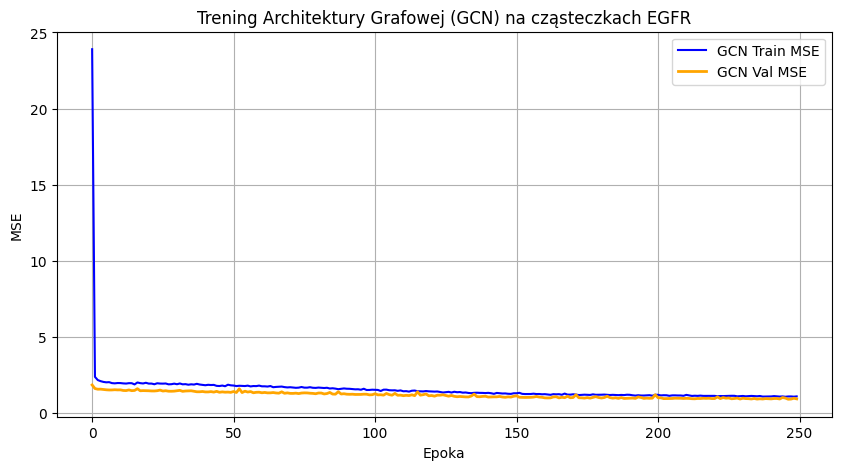


[EWALUACJA OSTATECZNA] ROC-AUC na kompletnie ślepym zbiorze Testowym: 0.8766


In [22]:
plt.figure(figsize=(10, 5))
plt.plot(train_h, label="GCN Train MSE", color="blue")
plt.plot(val_h, label="GCN Val MSE", color="orange", linewidth=2)
plt.title("Trening Architektury Grafowej (GCN) na cząsteczkach EGFR")
plt.ylabel("MSE")
plt.xlabel("Epoka")
plt.legend()
plt.grid(True)
plt.show()

# Obliczenie AUC
model.eval()
all_true, all_pred = [], []

with torch.no_grad():
    for data in test_loader: # Tutaj celowo bierzemy zbiór prawdziwie ślepy (Test Set)
        data = data.to(device)
        out = model(data.x, data.edge_index, data.batch)
        
        all_pred.extend(out.detach().cpu().flatten().tolist())
        all_true.extend(data.y.cpu().flatten().tolist())

all_true = np.array(all_true)
all_pred = np.array(all_pred)

threshold = 6.0
binary_true = (all_true >= threshold).astype(int)

try:
    auc = roc_auc_score(binary_true, all_pred)
    print(f"\n[EWALUACJA OSTATECZNA] ROC-AUC na kompletnie ślepym zbiorze Testowym: {auc:.4f}")
except Exception as e:
    print("Błąd AUC - za mało danych w batchu testowym:", e)

# %%


In [23]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Obliczanie metryk regresji dla modelu GNN
r2 = r2_score(all_true, all_pred)
mae = mean_absolute_error(all_true, all_pred)
rmse = np.sqrt(mean_squared_error(all_true, all_pred))

print("==================================================")
print(" Wyniki regresji (przewidywanie wartości pChEMBL)")
print("==================================================")
print(f" R^2 Score (Współczynnik determinacji): {r2:.4f}")
print(f" MAE (Średni błąd bezwzględny): {mae:.4f}")
print(f" RMSE (Pierwiastek błędu średniokwadratowego): {rmse:.4f}")


 Wyniki regresji (przewidywanie wartości pChEMBL)
 R^2 Score (Współczynnik determinacji): 0.4362
 MAE (Średni błąd bezwzględny): 0.7431
 RMSE (Pierwiastek błędu średniokwadratowego): 0.9530
